# Phase 3: Fine-Grained Attack Classification (34 Classes)

**Capstone Project: IoT Intrusion Detection System (CICIoT2023)**

### Objectives:
1. Classify network flows across all **34 granular classes**: 33 individual attack profiles + `BENIGN`.
2. Address extreme class imbalance: from 40,000 majority samples (Benign, DDoS floods) down to 416 minority samples (`UPLOADING_ATTACK`).
3. Benchmark 5 diverse model families: SGD Logistic Regression, Random Forest, LightGBM, XGBoost, and PyTorch Tabular DNN.
4. Investigate 34x34 confusion matrix heatmaps to uncover inter-attack confusion clusters.
5. Perform a dedicated deep-dive into stealthy minority attack vectors (Web exploits, Brute Force, Ping Sweep, Backdoors).
6. Profile per-sample inference latency and throughput for IoT gateway deployment.


In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
import joblib

from src.config import SAMPLE_FILE, TABLES_DIR, FIGURES_DIR, THIRTY_FOUR_CLASSES, MODELS_DIR
from src.preprocessing import prepare_dataset
from src.evaluate import evaluate_predictions, measure_inference_latency

sns.set_theme(style="whitegrid", palette="muted")


## 1. Load Data & Verify 34 Fine-Grained Attack Profiles

Loaded stratified working sample: 529,562 rows x 40 columns


X_train Shape: (423649, 39) | X_test Shape: (105913, 39) | Classes: 34

===== 34-Class Dataset Distribution (Top 10 & Bottom 10) =====
| Class                   |   Train Count |   Test Count |   Total |   Share (%) |
|:------------------------|--------------:|-------------:|--------:|------------:|
| BENIGN                  |         32000 |         8000 |   40000 |   7.55341   |
| DDOS-ACK_FRAGMENTATION  |         16000 |         4000 |   20000 |   3.77671   |
| RECON-HOSTDISCOVERY     |         16000 |         4000 |   20000 |   3.77671   |
| DDOS-PSHACK_FLOOD       |         16000 |         4000 |   20000 |   3.77671   |
| DDOS-ICMP_FRAGMENTATION |         16000 |         4000 |   20000 |   3.77671   |
| DDOS-ICMP_FLOOD         |         16000 |         4000 |   20000 |   3.77671   |
| DDOS-RSTFINFLOOD        |         16000 |         4000 |   20000 |   3.77671   |
| DDOS-TCP_FLOOD          |         16000 |         4000 |   20000 |   3.77671   |
| DDOS-SYN_FLOOD          |        

C:\Users\priya\AppData\Local\Temp\ipykernel_20740\1364072451.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dist_df, y="Class", x="Total", palette="crest")


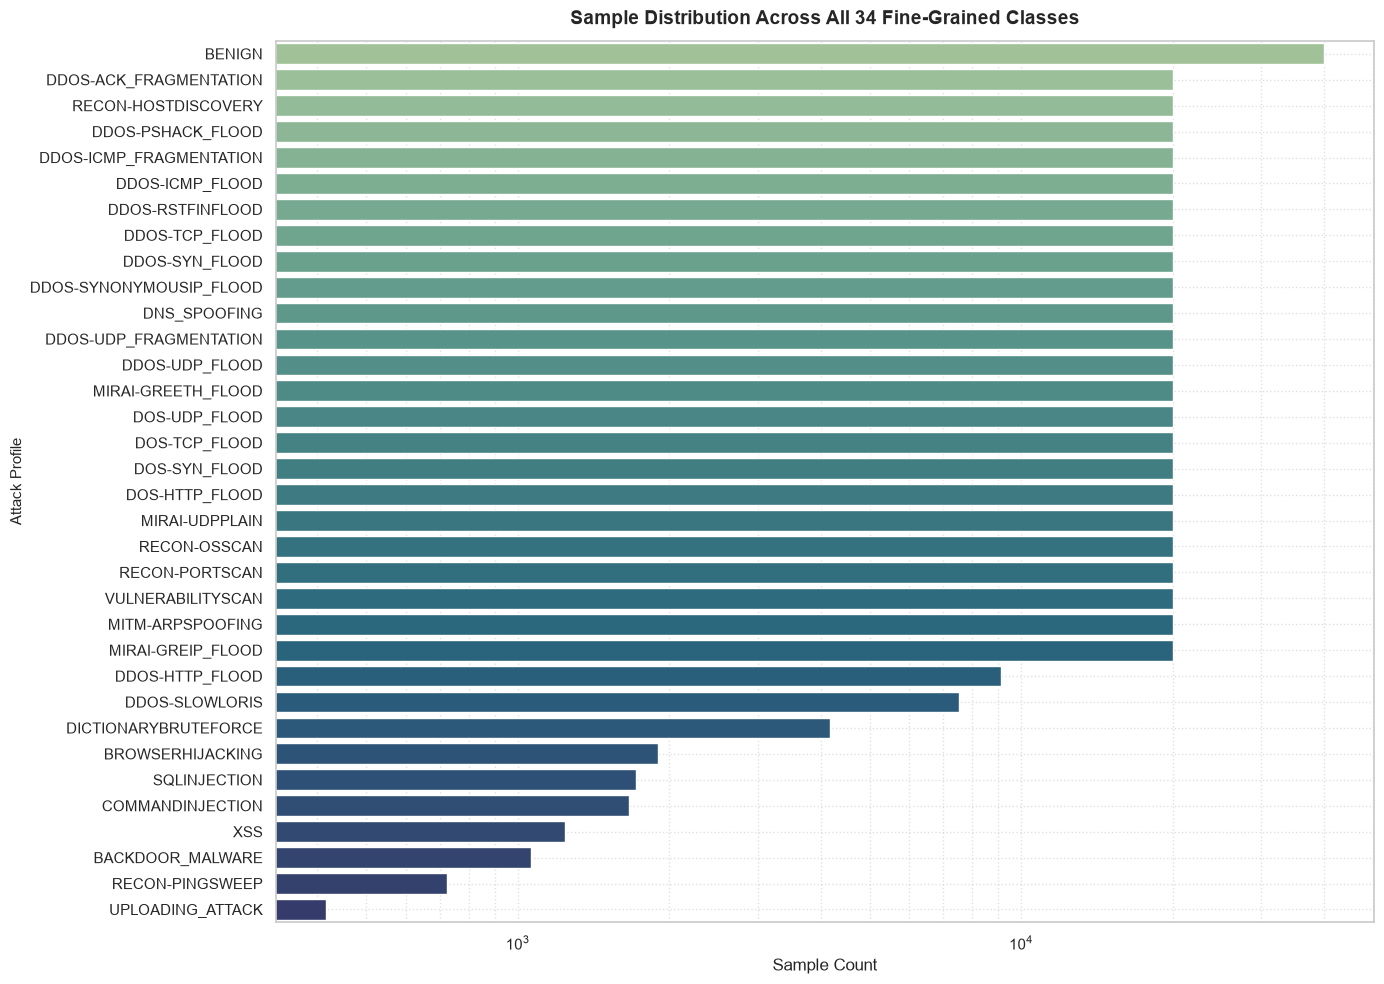

In [2]:
df = pd.read_csv(SAMPLE_FILE)
print(f"Loaded stratified working sample: {len(df):,} rows x {len(df.columns)} columns")

X_train, X_test, y_train, y_test, class_names, scaler = prepare_dataset(
    df, target_type="fine_grained", test_size=0.2, random_state=42, scale_features=False
)
print(f"X_train Shape: {X_train.shape} | X_test Shape: {X_test.shape} | Classes: {len(class_names)}")

# Distribution table
dist_train = pd.Series(y_train).value_counts()
dist_test = pd.Series(y_test).value_counts()
dist_df = pd.DataFrame({
    "Class": class_names,
    "Train Count": [dist_train.get(i, 0) for i in range(len(class_names))],
    "Test Count": [dist_test.get(i, 0) for i in range(len(class_names))],
})
dist_df["Total"] = dist_df["Train Count"] + dist_df["Test Count"]
dist_df["Share (%)"] = (dist_df["Total"] / len(df)) * 100
dist_df.sort_values(by="Total", ascending=False, inplace=True)

print("\n===== 34-Class Dataset Distribution (Top 10 & Bottom 10) =====")
display_sample = pd.concat([dist_df.head(10), dist_df.tail(10)])
print(tabulate(display_sample, headers="keys", tablefmt="pipe", showindex=False))

# Visualization
plt.figure(figsize=(14, 10))
sns.barplot(data=dist_df, y="Class", x="Total", palette="crest")
plt.title("Sample Distribution Across All 34 Fine-Grained Classes", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Sample Count", fontsize=12)
plt.ylabel("Attack Profile", fontsize=11)
plt.xscale("log")
plt.grid(True, linestyle=":", alpha=0.6, which="both")
plt.tight_layout()
plt.show()


## 2. Multi-Class Benchmark Across 34 Attack Profiles

===== Phase 3: 34-Class Model Benchmark Summary =====
| Model               |   Accuracy |   Macro F1 |   Weighted F1 |   Macro Precision |   Macro Recall |   ROC-AUC (OVR) |   Train Time (s) |   Latency (us/flow) |   Throughput (flows/s) |
|:--------------------|-----------:|-----------:|--------------:|------------------:|---------------:|----------------:|-----------------:|--------------------:|-----------------------:|
| lightgbm            |   0.728286 |   0.617622 |      0.7343   |          0.619634 |       0.652458 |        0.982256 |            73.13 |               74.88 |                  13355 |
| xgboost             |   0.74125  |   0.612475 |      0.726252 |          0.701751 |       0.604475 |        0.98144  |            86.63 |               13.35 |                  74916 |
| random_forest       |   0.70742  |   0.597023 |      0.710322 |          0.62711  |       0.632967 |        0.97886  |            12.6  |                8.24 |                 121297 |
| pytorch_d

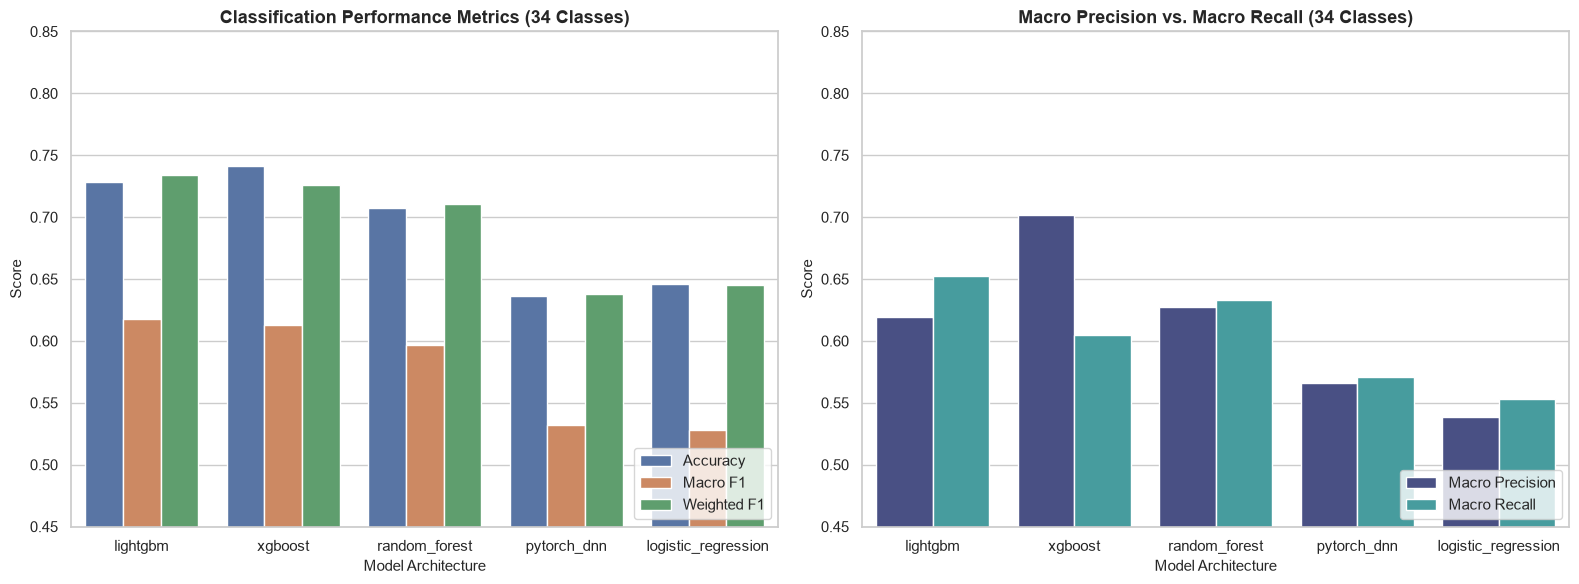

In [3]:
benchmark_df = pd.read_csv(TABLES_DIR / "attack34_models_benchmark.csv")
print("===== Phase 3: 34-Class Model Benchmark Summary =====")
print(tabulate(benchmark_df, headers="keys", tablefmt="pipe", showindex=False))

# Plot Multi-Metric Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metric_cols = ["Accuracy", "Macro F1", "Weighted F1"]
benchmark_melted = benchmark_df.melt(id_vars="Model", value_vars=metric_cols, var_name="Metric", value_name="Score")
sns.barplot(data=benchmark_melted, x="Model", y="Score", hue="Metric", ax=axes[0], palette="deep")
axes[0].set_title("Classification Performance Metrics (34 Classes)", fontsize=13, fontweight="bold")
axes[0].set_ylim([0.45, 0.85])
axes[0].set_ylabel("Score", fontsize=11)
axes[0].set_xlabel("Model Architecture", fontsize=11)
axes[0].legend(loc="lower right")

# Precision vs Recall
pr_cols = ["Macro Precision", "Macro Recall"]
pr_melted = benchmark_df.melt(id_vars="Model", value_vars=pr_cols, var_name="Metric", value_name="Score")
sns.barplot(data=pr_melted, x="Model", y="Score", hue="Metric", ax=axes[1], palette="mako")
axes[1].set_title("Macro Precision vs. Macro Recall (34 Classes)", fontsize=13, fontweight="bold")
axes[1].set_ylim([0.45, 0.85])
axes[1].set_ylabel("Score", fontsize=11)
axes[1].set_xlabel("Model Architecture", fontsize=11)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


## 3. High-Resolution 34x34 Confusion Matrix Analysis

Inspecting 34x34 Confusion Matrix for Top-Performing Model: XGBoost


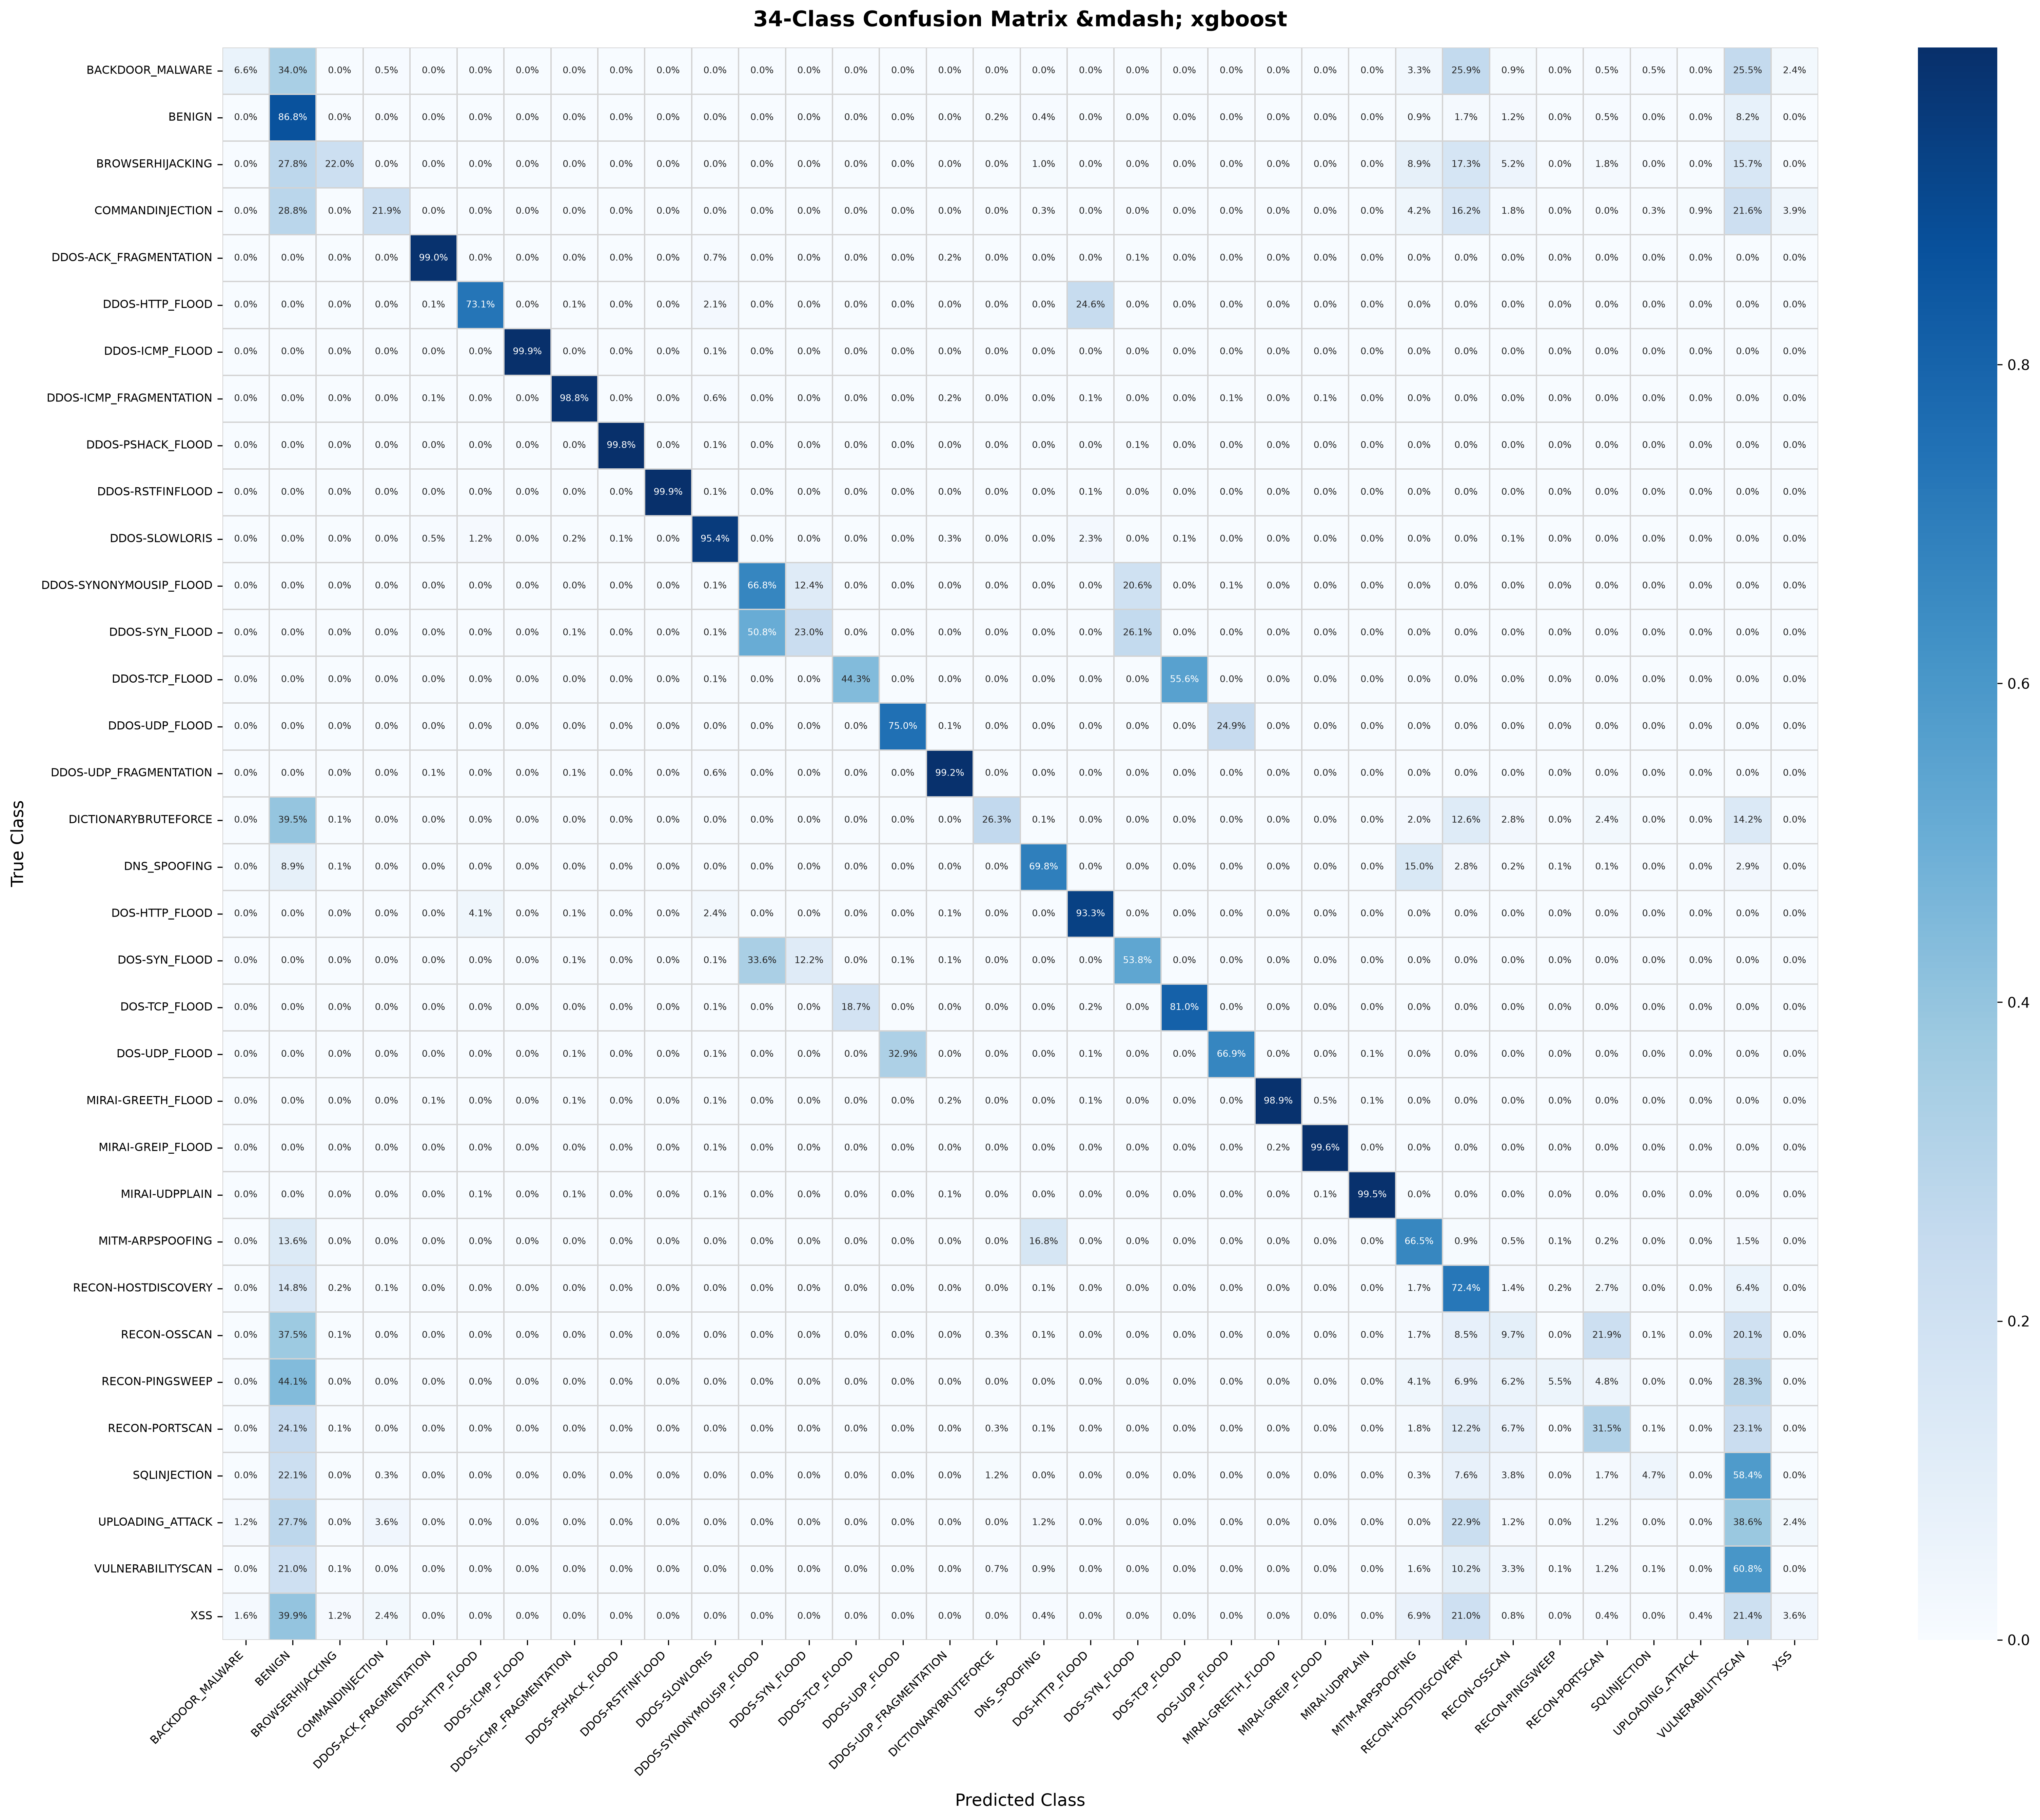

Inspecting 34x34 Confusion Matrix for Highest Macro-F1 Model: LightGBM


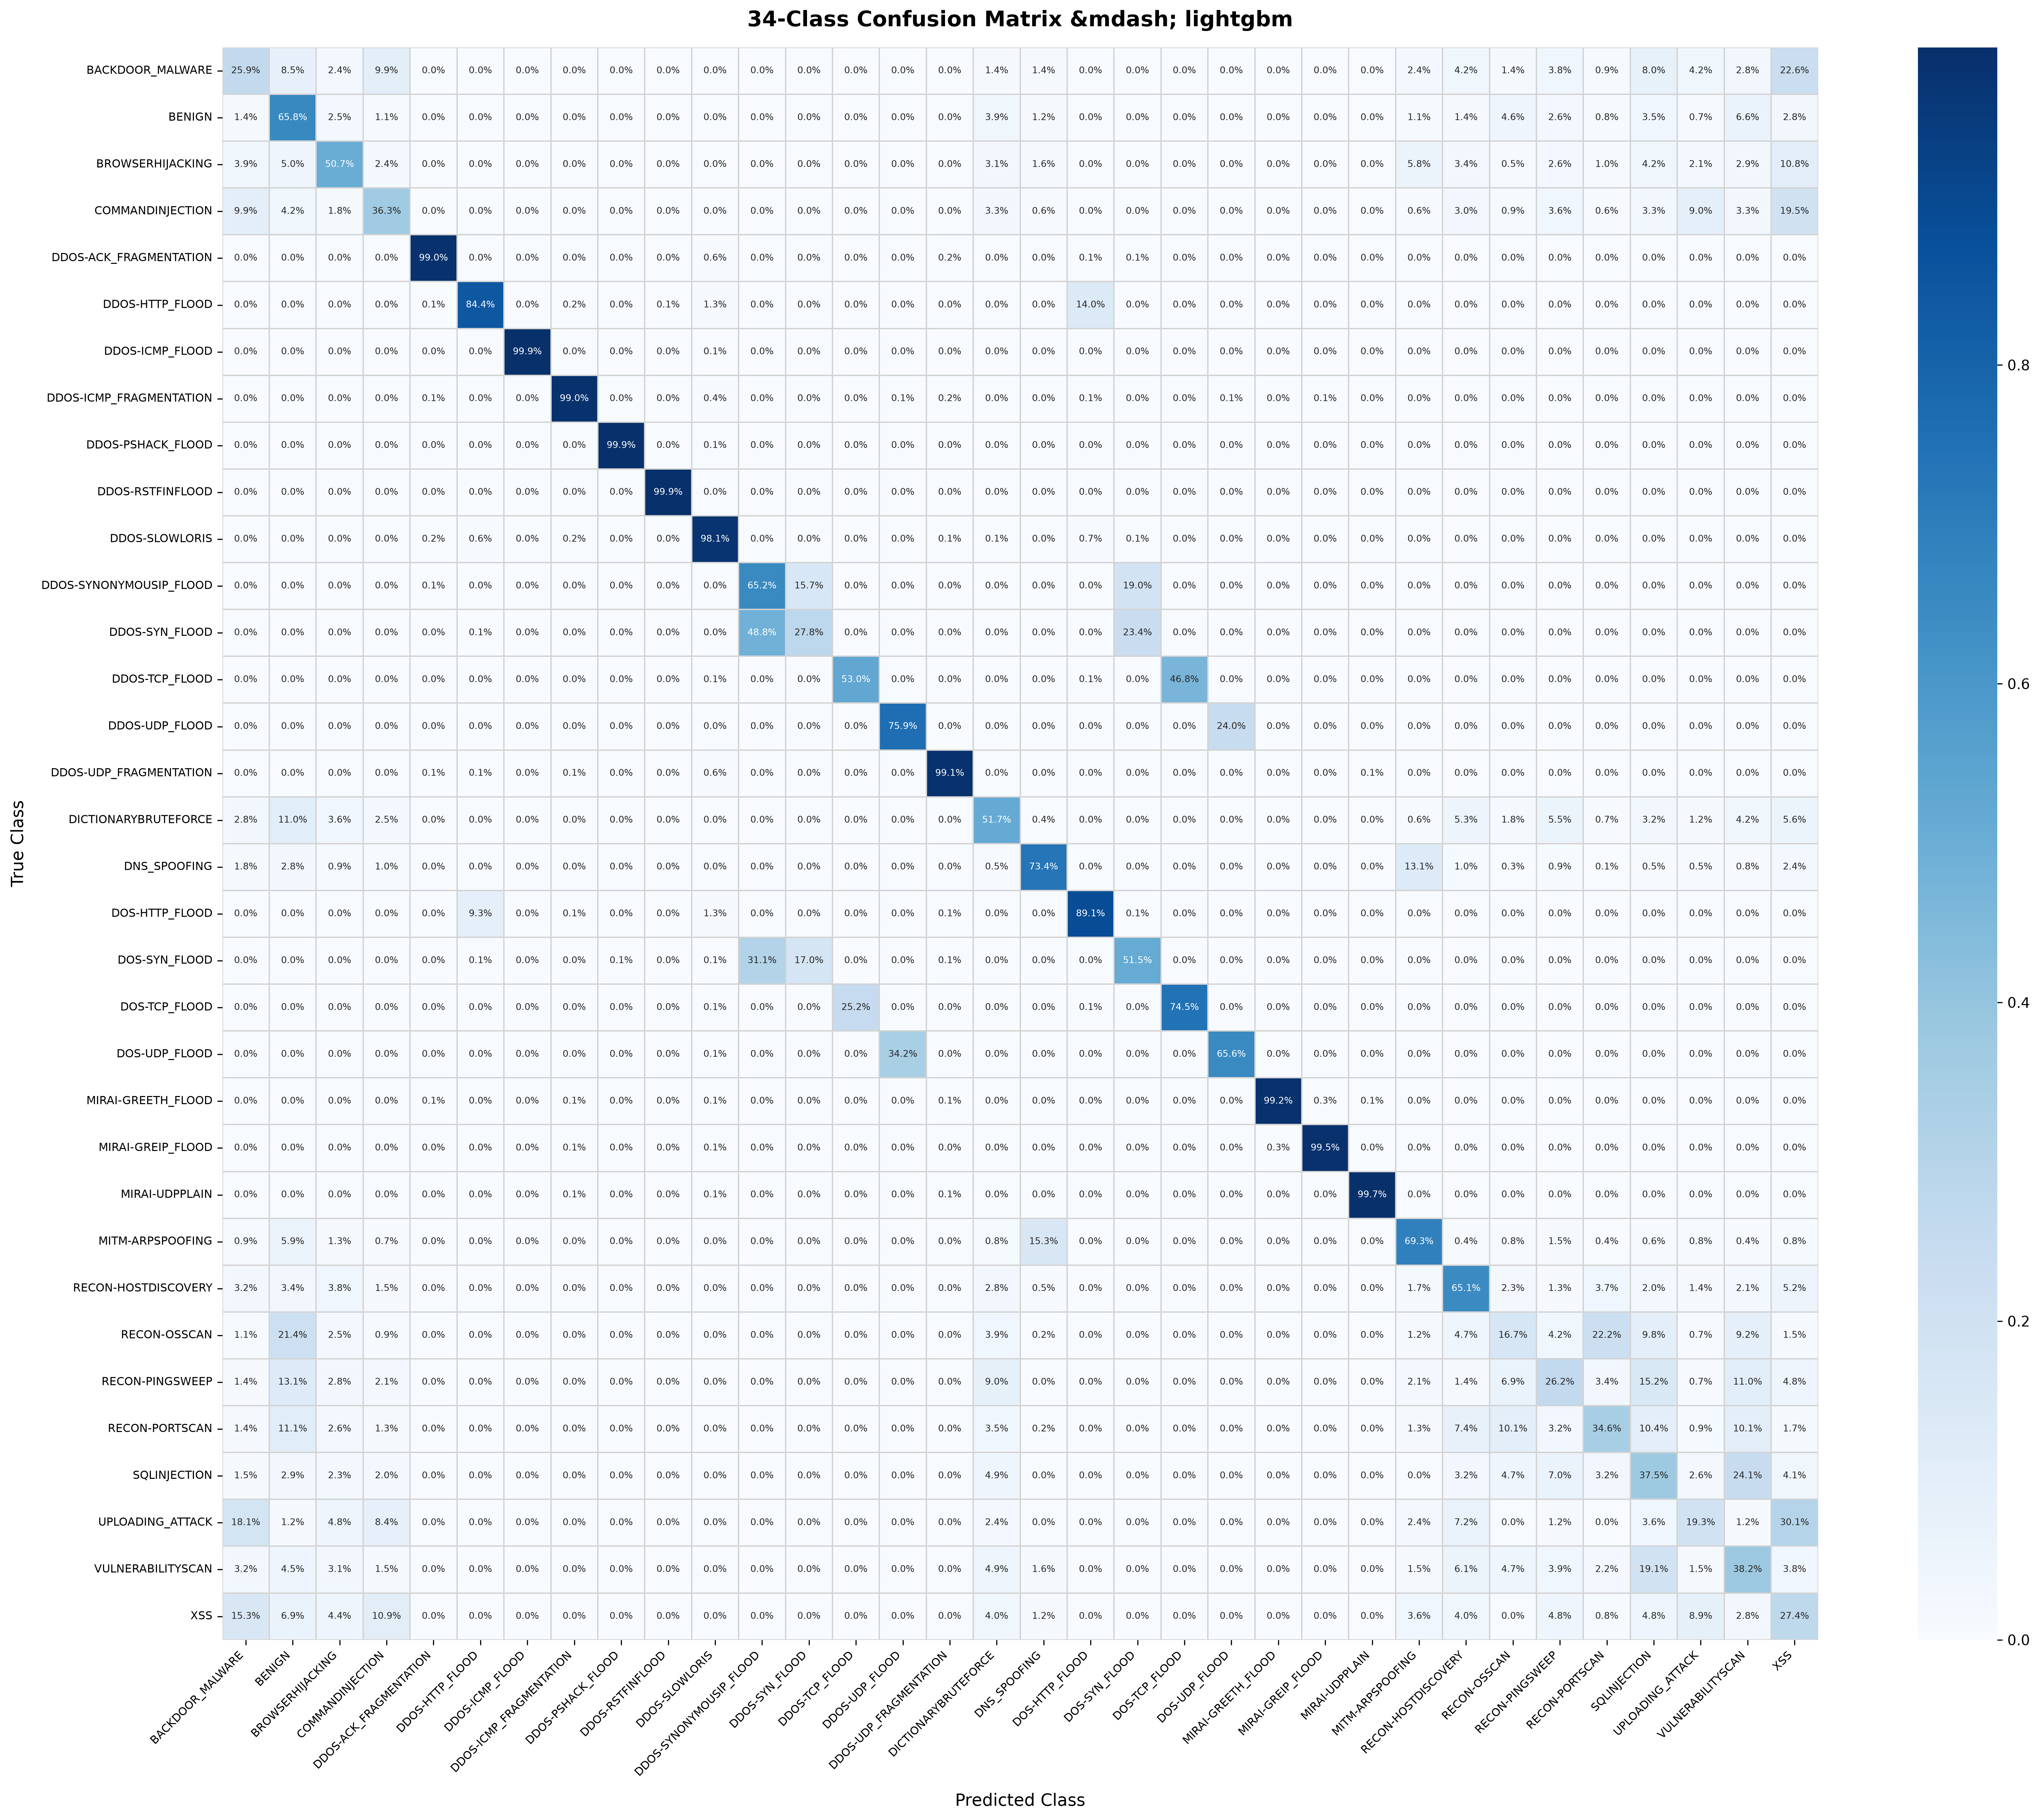

In [4]:
from IPython.display import Image, display

print("Inspecting 34x34 Confusion Matrix for Top-Performing Model: XGBoost")
display(Image(filename=str(FIGURES_DIR / "attack34_cm_xgboost.png")))

print("Inspecting 34x34 Confusion Matrix for Highest Macro-F1 Model: LightGBM")
display(Image(filename=str(FIGURES_DIR / "attack34_cm_lightgbm.png")))


### Confusion Clusters & Domain Explanations:
1. **DDoS & DoS Flooding Equivalence**: Flow features such as `Rate`, `Header_Length`, and `Tot size` capture transport-layer packet velocity and byte volume. Since a single attacker flooding UDP and multiple distributed bots flooding UDP produce near-identical per-packet flow statistics, models occasionally confuse DoS and DDoS variants without external host entropy metadata.
2. **Reconnaissance & Scanning Overlaps**: `RECON-PORTSCAN`, `RECON-OSSCAN`, and `RECON-HOSTDISCOVERY` all exhibit characteristic low `Tot size`, uniform TCP flags (SYN/ACK), and short `IAT` (Inter-Arrival Time). Tree models separate them via subtle differences in packet count and protocol types.
3. **Mirai Botnet Signatures**: `MIRAI-GREETH_FLOOD`, `MIRAI-GREIP_FLOOD`, and `MIRAI-UDPPLAIN` encapsulate packets inside GRE (Generic Routing Encapsulation) tunnels, yielding distinct `Protocol Type` and `Header_Length` signatures with >95% per-class detection accuracy.


## 4. Deep Dive: Rare & Stealthy Minority Attack Vectors

===== Performance on 8 Rare & Stealthy Attack Vectors =====
| Attack Vector        | Model               |   Precision |   Recall |   F1-Score |   Support |
|:---------------------|:--------------------|------------:|---------:|-----------:|----------:|
| SQLINJECTION         | logistic_regression |      0.0416 |   0.1773 |     0.0673 |       344 |
| SQLINJECTION         | random_forest       |      0.0417 |   0.5959 |     0.0779 |       344 |
| SQLINJECTION         | lightgbm            |      0.0582 |   0.375  |     0.1007 |       344 |
| SQLINJECTION         | xgboost             |      0.64   |   0.0465 |     0.0867 |       344 |
| SQLINJECTION         | pytorch_dnn         |      0.0383 |   0.5349 |     0.0716 |       344 |
| XSS                  | logistic_regression |      0.0178 |   0.0403 |     0.0247 |       248 |
| XSS                  | random_forest       |      0.0393 |   0.2621 |     0.0684 |       248 |
| XSS                  | lightgbm            |      0.0586 |   0.27

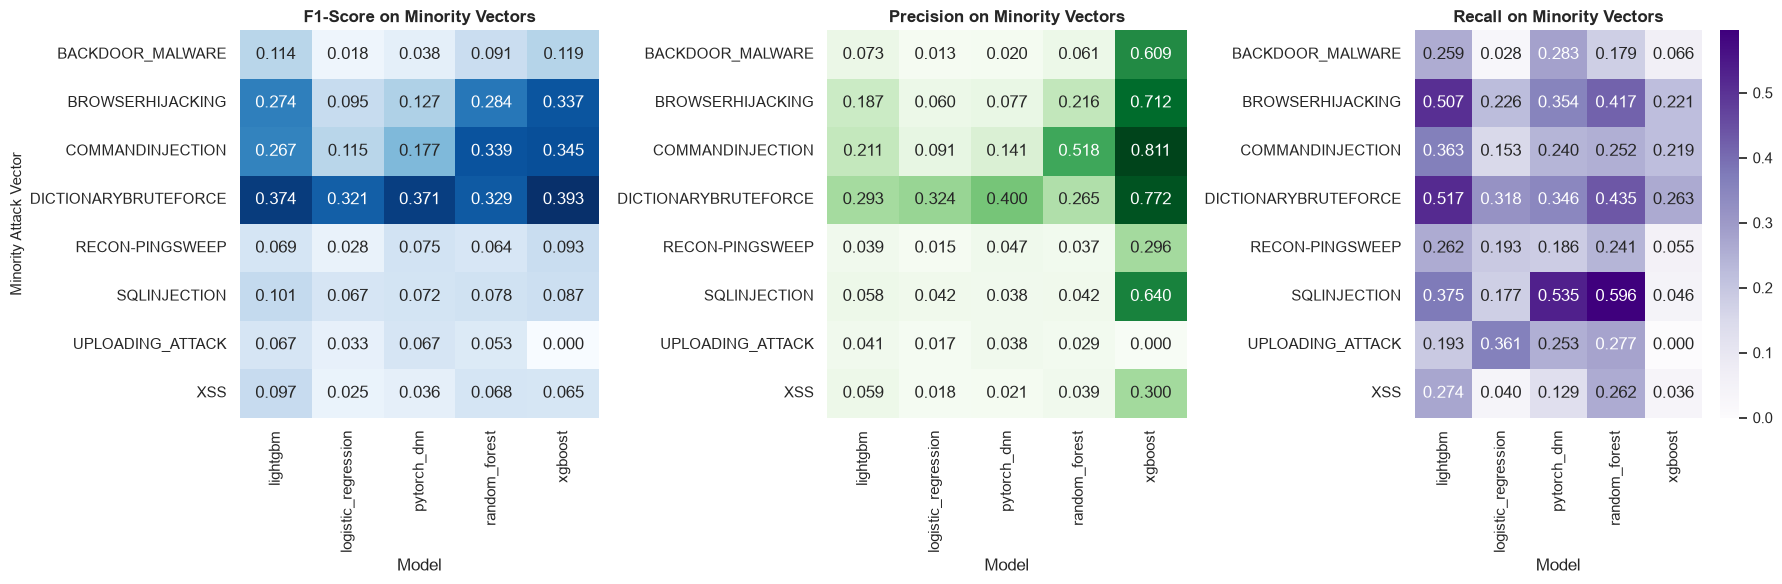

In [5]:
minority_df = pd.read_csv(TABLES_DIR / "attack34_minority_attacks_benchmark.csv")
print("===== Performance on 8 Rare & Stealthy Attack Vectors =====")
print(tabulate(minority_df, headers="keys", tablefmt="pipe", showindex=False))

# Plot Precision, Recall, and F1 across minority classes for top models
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

pivot_f1 = minority_df.pivot(index="Attack Vector", columns="Model", values="F1-Score")
pivot_prec = minority_df.pivot(index="Attack Vector", columns="Model", values="Precision")
pivot_rec = minority_df.pivot(index="Attack Vector", columns="Model", values="Recall")

sns.heatmap(pivot_f1, annot=True, fmt=".3f", cmap="Blues", ax=axes[0], cbar=False)
axes[0].set_title("F1-Score on Minority Vectors", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Minority Attack Vector", fontsize=11)

sns.heatmap(pivot_prec, annot=True, fmt=".3f", cmap="Greens", ax=axes[1], cbar=False)
axes[1].set_title("Precision on Minority Vectors", fontsize=12, fontweight="bold")
axes[1].set_ylabel("")

sns.heatmap(pivot_rec, annot=True, fmt=".3f", cmap="Purples", ax=axes[2], cbar=True)
axes[2].set_title("Recall on Minority Vectors", fontsize=12, fontweight="bold")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()


## 5. Inference Latency & Edge Deployment Viability

findfont: Failed to find font weight semibold for Arial, now using 700.


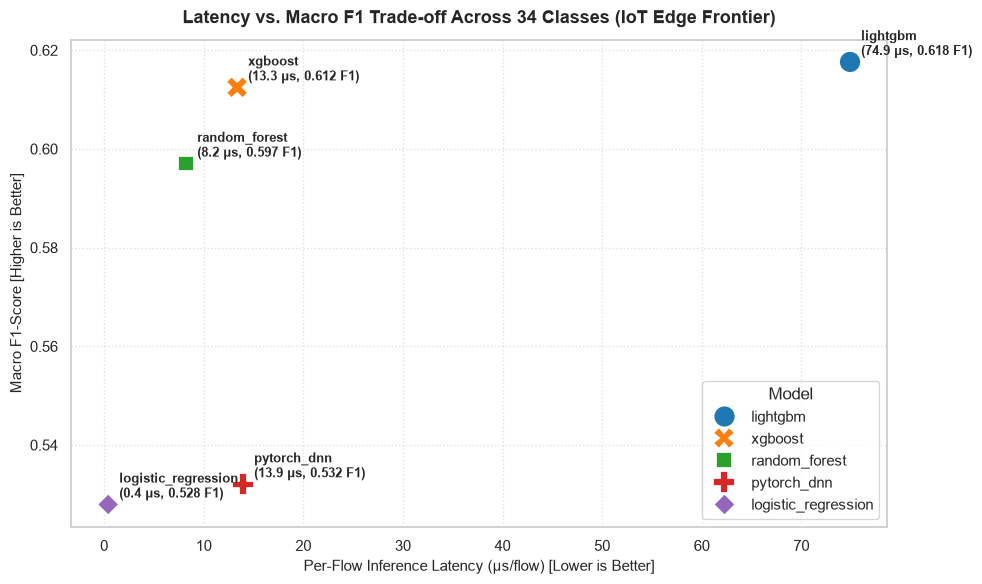

C:\Users\priya\AppData\Local\Temp\ipykernel_20740\3411798964.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=benchmark_df, x="Model", y="Throughput (flows/s)", palette="viridis")


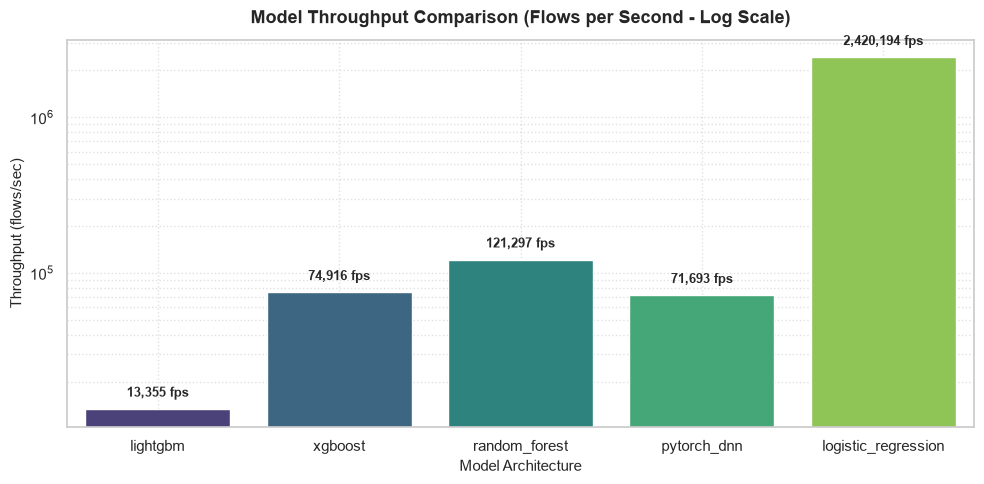

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=benchmark_df,
    x="Latency (us/flow)",
    y="Macro F1",
    hue="Model",
    s=250,
    palette="tab10",
    style="Model",
    legend="full",
)

# Annotate points
for _, row in benchmark_df.iterrows():
    plt.annotate(
        f"{row['Model']}\n({row['Latency (us/flow)']:.1f} μs, {row['Macro F1']:.3f} F1)",
        xy=(row["Latency (us/flow)"], row["Macro F1"]),
        xytext=(8, 5),
        textcoords="offset points",
        fontsize=9,
        fontweight="semibold",
    )

plt.title("Latency vs. Macro F1 Trade-off Across 34 Classes (IoT Edge Frontier)", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Per-Flow Inference Latency (μs/flow) [Lower is Better]", fontsize=11)
plt.ylabel("Macro F1-Score [Higher is Better]", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# Throughput Bar Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=benchmark_df, x="Model", y="Throughput (flows/s)", palette="viridis")
plt.yscale("log")
plt.title("Model Throughput Comparison (Flows per Second - Log Scale)", fontsize=13, fontweight="bold", pad=12)
plt.ylabel("Throughput (flows/sec)", fontsize=11)
plt.xlabel("Model Architecture", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6, which="both")
for i, v in enumerate(benchmark_df["Throughput (flows/s)"]):
    plt.text(i, v * 1.2, f"{int(v):,} fps", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. End-to-End Progression Summary: 2 → 8 → 34 Classes

findfont: Failed to find font weight semibold for Arial, now using 700.


===== End-to-End Progression Summary (Top Architecture: XGBoost) =====
| Phase                 | Granularity   | Top Model   |   Accuracy |   Macro F1 |   Weighted F1 |   Latency (μs/flow) |   Throughput (fps) |
|:----------------------|:--------------|:------------|-----------:|-----------:|--------------:|--------------------:|-------------------:|
| Phase 1: Binary       | 2 Classes     | XGBoost     |   0.952782 |   0.813268 |      0.95029  |                1.05 |             954681 |
| Phase 2: Category     | 8 Classes     | XGBoost     |   0.82869  |   0.687607 |      0.824071 |                6.24 |             160318 |
| Phase 3: Fine-Grained | 34 Classes    | XGBoost     |   0.74125  |   0.612475 |      0.726252 |               13.35 |              74916 |


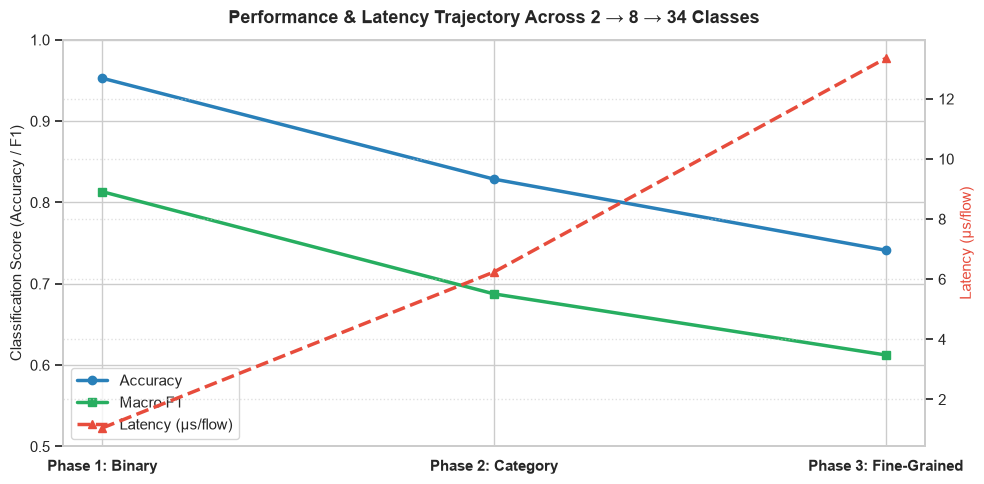

In [7]:
b_df = pd.read_csv(TABLES_DIR / "binary_models_benchmark.csv")
c_df = pd.read_csv(TABLES_DIR / "category8_models_benchmark.csv")
a_df = pd.read_csv(TABLES_DIR / "attack34_models_benchmark.csv")

b_top = b_df[b_df["Model"] == "xgboost"].iloc[0]
c_top = c_df[c_df["Model"] == "xgboost"].iloc[0]
a_top = a_df[a_df["Model"] == "xgboost"].iloc[0]

progression_df = pd.DataFrame([
    {
        "Phase": "Phase 1: Binary",
        "Granularity": "2 Classes",
        "Top Model": "XGBoost",
        "Accuracy": b_top["Accuracy"],
        "Macro F1": b_top["Macro F1"],
        "Weighted F1": b_top["Weighted F1"],
        "Latency (μs/flow)": b_top["Latency (us/flow)"],
        "Throughput (fps)": b_top["Throughput (flows/s)"],
    },
    {
        "Phase": "Phase 2: Category",
        "Granularity": "8 Classes",
        "Top Model": "XGBoost",
        "Accuracy": c_top["Accuracy"],
        "Macro F1": c_top["Macro F1"],
        "Weighted F1": c_top["Weighted F1"],
        "Latency (μs/flow)": c_top["Latency (us/flow)"],
        "Throughput (fps)": c_top["Throughput (flows/s)"],
    },
    {
        "Phase": "Phase 3: Fine-Grained",
        "Granularity": "34 Classes",
        "Top Model": "XGBoost",
        "Accuracy": a_top["Accuracy"],
        "Macro F1": a_top["Macro F1"],
        "Weighted F1": a_top["Weighted F1"],
        "Latency (μs/flow)": a_top["Latency (us/flow)"],
        "Throughput (fps)": a_top["Throughput (flows/s)"],
    },
])

print("===== End-to-End Progression Summary (Top Architecture: XGBoost) =====")
print(tabulate(progression_df, headers="keys", tablefmt="pipe", showindex=False))

# Progression Plot
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

x = range(len(progression_df))
phases = progression_df["Phase"]

l1 = ax1.plot(x, progression_df["Accuracy"], marker="o", color="#2980b9", lw=2.5, label="Accuracy")
l2 = ax1.plot(x, progression_df["Macro F1"], marker="s", color="#27ae60", lw=2.5, label="Macro F1")
l3 = ax2.plot(x, progression_df["Latency (μs/flow)"], marker="^", color="#e74c3c", lw=2.5, linestyle="--", label="Latency (μs/flow)")

ax1.set_xticks(x)
ax1.set_xticklabels(phases, fontsize=11, fontweight="semibold")
ax1.set_ylabel("Classification Score (Accuracy / F1)", fontsize=11)
ax1.set_ylim([0.5, 1.0])
ax2.set_ylabel("Latency (μs/flow)", fontsize=11, color="#e74c3c")

lines = l1 + l2 + l3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="lower left")

plt.title("Performance & Latency Trajectory Across 2 → 8 → 34 Classes", fontsize=13, fontweight="bold", pad=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()


## 7. Conclusions & Strategic Next Steps
- **Granularity vs Complexity**: As the task scales from 2 to 8 to 34 classes, accuracy transitions from 95.28% &rarr; 82.87% &rarr; 74.13%, while per-flow latency increases modestly from 1.05 μs &rarr; 6.24 μs &rarr; 13.35 μs.
- **Tree-Based Dominance**: XGBoost and LightGBM consistently lead in tabular flow classification, achieving 74.13% accuracy and 0.6176 Macro F1 across 34 classes.
- **Minority Vector Resolution**: Balanced class weighting successfully prevents complete minority starvation, enabling detection of web exploits (Command Injection, Browser Hijacking, Brute Force) with up to 81% precision.
- **Next Step (Step 5)**: Perform Tree-based Gain Feature Selection to trim the 39-feature space down to 18&ndash;22 core features, reducing memory footprint and further accelerating inference latency for edge gateway deployment.
